# Auditing the Sage-resampled CROCUS archive

Companion to `audit_essdive.ipynb`, but pointed at the **resampled archive we build from
the Sage/Waggle continuum** rather than the ESS-DIVE publication. Same idea, same coverage
math, same deployment-aware overlay — only the input directory, the filename pattern, and
the cadence differ.

- **Input:** `data/sage_resampled/<SITE>_<instr>_5min.nc` (5-minute resampled cadence).
- **Output:** a coverage heatmap `figures/sage_resampled_coverage_deployment.png`.

**One extra wrinkle vs. ESS-DIVE:** the AQT reports two physically independent subsystems —
the **particulate (PM) optical module** and the **electrochemical gas cells**. The PM module
sometimes fails while the gases keep reporting (or vice-versa). A single AQT coverage number
hides that. So every `*_aqt_*` file is split into **two rows** — `<SITE>_aqt_pm` and
`<SITE>_aqt_gas` — each scored on the coverage of *its own* variables. WXT files stay as one
row.

Coverage semantics are identical to the ESS-DIVE audit:
- **grey** = instrument not deployed that month (from the `crocus_sites` registry);
- **colour** = deployed and data present, shaded by coverage fraction (viridis, 0–1);
- **white** = deployed but no data that month → a genuine gap / still to backfill.


In [8]:
import glob
import os

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import crocus_sites as cs

In [9]:
ARCHIVEDIR = "data/sage_resampled"
PATTERN    = "*_5min.nc"
FIGDIR     = "figures/resampled"
os.makedirs(FIGDIR, exist_ok=True)

## AQT PM vs. gas variable groups

We don't hardcode the AQT variable list — we classify each file's actual variables into
**PM** vs **gas** by name, so the split survives naming variants (`pm2.5`, `pm2_5`, `pm25`)
and schema drift. Anything matching a PM token is PM; anything matching a known gas /
gas-support token is gas. Variables matching neither (housekeeping, lat/lon, qc flags) are
ignored for coverage. A quick print lets you eyeball the classification per file.

In [10]:
# Token-based classifier for AQT variables.
# PM: optical particulate module.  GAS: electrochemical cells + their onboard T/RH/P.
_PM_TOKENS  = ("pm1", "pm2", "pm4", "pm10", "pm25", "pm2_5", "pm2.5",
               "particle", "particulate", "opc", "bin")
_GAS_TOKENS = ("co", "co2", "no", "no2", "nox", "o3", "so2",
               "ozone", "gas")
# T/RH/P live on the gas board; treat as gas-side housekeeping so a dead PM module
# doesn't drag them down (and vice-versa). Adjust if your schema differs.
_GAS_SUPPORT_TOKENS = ("temperature", "temp", "_t", "rh", "humidity",
                       "pressure", "press", "dewpoint", "dew_point")

def _tok(name):
    return name.lower()

def classify_aqt_var(name):
    """Return 'pm', 'gas', or None for one AQT variable name."""
    n = _tok(name)
    if any(t in n for t in _PM_TOKENS):
        return "pm"
    if any(t in n for t in _GAS_TOKENS):
        return "gas"
    if any(t in n for t in _GAS_SUPPORT_TOKENS):
        return "gas"
    return None

def aqt_groups(ds):
    """Map {'pm': [vars], 'gas': [vars]} for an open AQT dataset."""
    groups = {"pm": [], "gas": []}
    for name in ds.data_vars:
        g = classify_aqt_var(name)
        if g in groups:
            groups[g].append(name)
    return groups

In [11]:
# Sanity-check the classification on whatever AQT files are present.
for f in sorted(glob.glob(os.path.join(ARCHIVEDIR, "*_aqt_*.nc"))):
    with xr.open_dataset(f) as ds:
        g = aqt_groups(ds)
    unclassified = [v for v in ds.data_vars
                    if classify_aqt_var(v) is None]
    print(os.path.basename(f))
    print(f"   PM  ({len(g['pm'])}): {sorted(g['pm'])}")
    print(f"   GAS ({len(g['gas'])}): {sorted(g['gas'])}")
    if unclassified:
        print(f"   (ignored: {sorted(unclassified)})")
    print()

ATMOS_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

BIG_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

CCICS_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

CSU_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

DOWN_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

HUM_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

NEIU_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

NU_aqt_5min.nc
   PM  (3): ['pm1', 'pm10', 'pm25']
   GAS (7): ['co', 'humidity', 'no', 'no2', 'o3', 'pressure', 'temp']

SHEDD_aqt_5

## Coverage table

Same coverage-fraction definition as the ESS-DIVE audit:

> coverage = (actual samples in month) / (expected samples in month),
> expected = seconds_in_month / median_sampling_step.

The median step is read from each file's own time axis, so the nominal 5-minute cadence is
picked up automatically (and any file resampled to a different step still scores correctly).

The one addition: for AQT files we compute the fraction **per subsystem**. A month counts a
sample toward PM only if at least one PM variable is finite there, and toward gas only if at
least one gas variable is finite there. So a dead PM module shows as a white/dark PM row
while the gas row stays bright.

**PM flatline rule.** The optical module fails by flatlining at exactly `0.000` across *all*
size channels at once, for stretches far too long and too machine-exact to be clean air. So a
PM bin counts as present only if `count > 0` **and** not every PM channel is exactly 0. Gas
and WXT are unaffected. The table cell prints, per site, how many PM bins this drops so you
can sanity-check the threshold.

In [12]:
def _frac_from_times(t):
    """coverage fraction Series (index = day) from a DatetimeIndex.

    Fraction = (real bins that day) / (bins a full day would hold at the
    data's native step). A near-empty day reads near 0 (dark), a full day 1.
    """
    if len(t) < 3:
        return None
    step_s = float(np.median(np.diff(t).astype("timedelta64[s]").astype(float)))
    if step_s <= 0:
        return None
    counts = pd.Series(1, index=t).resample("D").count()
    secs_in_day = counts.index.to_series().apply(
        lambda d: ((d + pd.Timedelta(days=1)) - d).total_seconds())
    return pd.Series(counts.values / (secs_in_day.values / step_s),
                     index=counts.index)

def _var_present(ds, v):
    """Boolean per-time 'this variable has real data in this bin'.

    Variables are (time, statistic) with statistic = mean/count/std. Prefer the
    'count' slot (a resampled bin with count==0 is not real data even if a mean
    is stored); fall back to 'any finite over the statistic axis' if there is no
    count slot or no statistic dim."""
    da = ds[v]
    stats = list(ds.attrs.get("statistics", "").replace(" ", "").split(","))
    if "statistic" in da.dims and "count" in stats:
        cnt = da.isel(statistic=stats.index("count")).values
        return np.nan_to_num(cnt, nan=0.0) > 0
    vals = da.values
    if vals.ndim > 1:
        return np.isfinite(vals).any(axis=tuple(range(1, vals.ndim)))
    return np.isfinite(vals)

def _present_times(ds, varnames, drop_pm_flatline=False):
    """Times where at least one of varnames has real data.

    If drop_pm_flatline is True, a bin where *every* PM channel reads exactly 0
    (mean slot) is treated as no data: the optical module flatlines at 0.000
    across all size bins when it fails, whereas genuine clean air is near-zero
    but not machine-exact and not sustained. This does not affect gas/WXT."""
    if not varnames:
        return pd.DatetimeIndex([])
    present = None
    for v in varnames:
        p = _var_present(ds, v)
        present = p if present is None else (present | p)

    if drop_pm_flatline:
        stats = list(ds.attrs.get("statistics", "").replace(" ", "").split(","))
        if "mean" in stats:
            mi = stats.index("mean")
            all_zero = None
            for v in varnames:
                mean = ds[v].isel(statistic=mi).values if "statistic" in ds[v].dims \
                    else ds[v].values
                is0 = (mean == 0)
                all_zero = is0 if all_zero is None else (all_zero & is0)
            if all_zero is not None:
                present = present & ~all_zero

    t = pd.to_datetime(ds["time"].values)
    return t[present]

def coverage_table(archive_dir=ARCHIVEDIR, pattern=PATTERN):
    """rows = site/instrument (AQT split into _pm/_gas), cols = months, val = coverage."""
    series = {}
    for f in sorted(glob.glob(os.path.join(archive_dir, pattern))):
        base = os.path.basename(f).replace("_5min.nc", "")     # e.g. NEIU_aqt
        with xr.open_dataset(f) as ds:
            if "aqt" in base.lower():
                groups = aqt_groups(ds)
                for sub in ("pm", "gas"):
                    drop = (sub == "pm")   # flatline rule applies to PM only
                    # report how many PM bins get dropped as stuck-zero
                    if drop and groups["pm"]:
                        t_raw = _present_times(ds, groups[sub], drop_pm_flatline=False)
                        t = _present_times(ds, groups[sub], drop_pm_flatline=True)
                        n_raw = len(t_raw)
                        if n_raw:
                            pct = 100.0 * (n_raw - len(t)) / n_raw
                            print(f"{base}_pm: dropped {n_raw - len(t):,} / {n_raw:,} "
                                  f"PM bins as all-zero flatline ({pct:.1f}%)")
                    else:
                        t = _present_times(ds, groups[sub], drop_pm_flatline=drop)
                    fr = _frac_from_times(pd.DatetimeIndex(sorted(t)))
                    if fr is not None:
                        series[f"{base}_{sub}"] = fr
            else:
                fr = _frac_from_times(pd.to_datetime(ds["time"].values))
                if fr is not None:
                    series[base] = fr
    if not series:
        return pd.DataFrame()
    df = pd.DataFrame(series).T
    return df.reindex(sorted(df.columns), axis=1)

cov = coverage_table()
cov if cov.empty else cov.round(2)

ATMOS_aqt_pm: dropped 7 / 143,605 PM bins as all-zero flatline (0.0%)
BIG_aqt_pm: dropped 38,009 / 99,216 PM bins as all-zero flatline (38.3%)
CCICS_aqt_pm: dropped 21 / 65,583 PM bins as all-zero flatline (0.0%)
CSU_aqt_pm: dropped 342 / 180,007 PM bins as all-zero flatline (0.2%)
DOWN_aqt_pm: dropped 54,073 / 81,427 PM bins as all-zero flatline (66.4%)
HUM_aqt_pm: dropped 4,048 / 78,674 PM bins as all-zero flatline (5.1%)
NEIU_aqt_pm: dropped 20,943 / 254,161 PM bins as all-zero flatline (8.2%)
NU_aqt_pm: dropped 33 / 208,076 PM bins as all-zero flatline (0.0%)
SHEDD_aqt_pm: dropped 3,229 / 72,263 PM bins as all-zero flatline (4.5%)
UIC_aqt_pm: dropped 59,925 / 145,861 PM bins as all-zero flatline (41.1%)
VLPK_aqt_pm: dropped 7,030 / 73,570 PM bins as all-zero flatline (9.6%)


,2023-05-05,2023-05-06,2023-05-07,2023-05-08,2023-05-09,2023-05-10,2023-05-11,2023-05-12,2023-05-13,2023-05-14,...,2025-12-07,2025-12-08,2025-12-09,2025-12-10,2025-12-11,2025-12-12,2025-12-13,2025-12-14,2025-12-15,2025-12-16
ATMOS_aqt_pm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,0.84
ATMOS_aqt_gas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,0.84
BIG_aqt_pm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.01,NaN,NaN
BIG_aqt_gas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,0.70
CCICS_aqt_pm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CCICS_aqt_gas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CCICS_wxt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CSU_aqt_pm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.76,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,NaN
CSU_aqt_gas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,NaN
CSU_wxt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,NaN


## Deployment-aware heatmap (intended network)

Identical overlay logic to the ESS-DIVE audit, using the shared `crocus_sites` registry so
"not deployed" is consistent across both notebooks. The only change: each site now expands to
**three** intended rows — `wxt`, `aqt_pm`, `aqt_gas` — and the deployment mask keys the two
AQT rows off the same `aqt` deployment window (PM and gas ship in the same box, so they share
a deployment date even when only one subsystem is currently reporting).

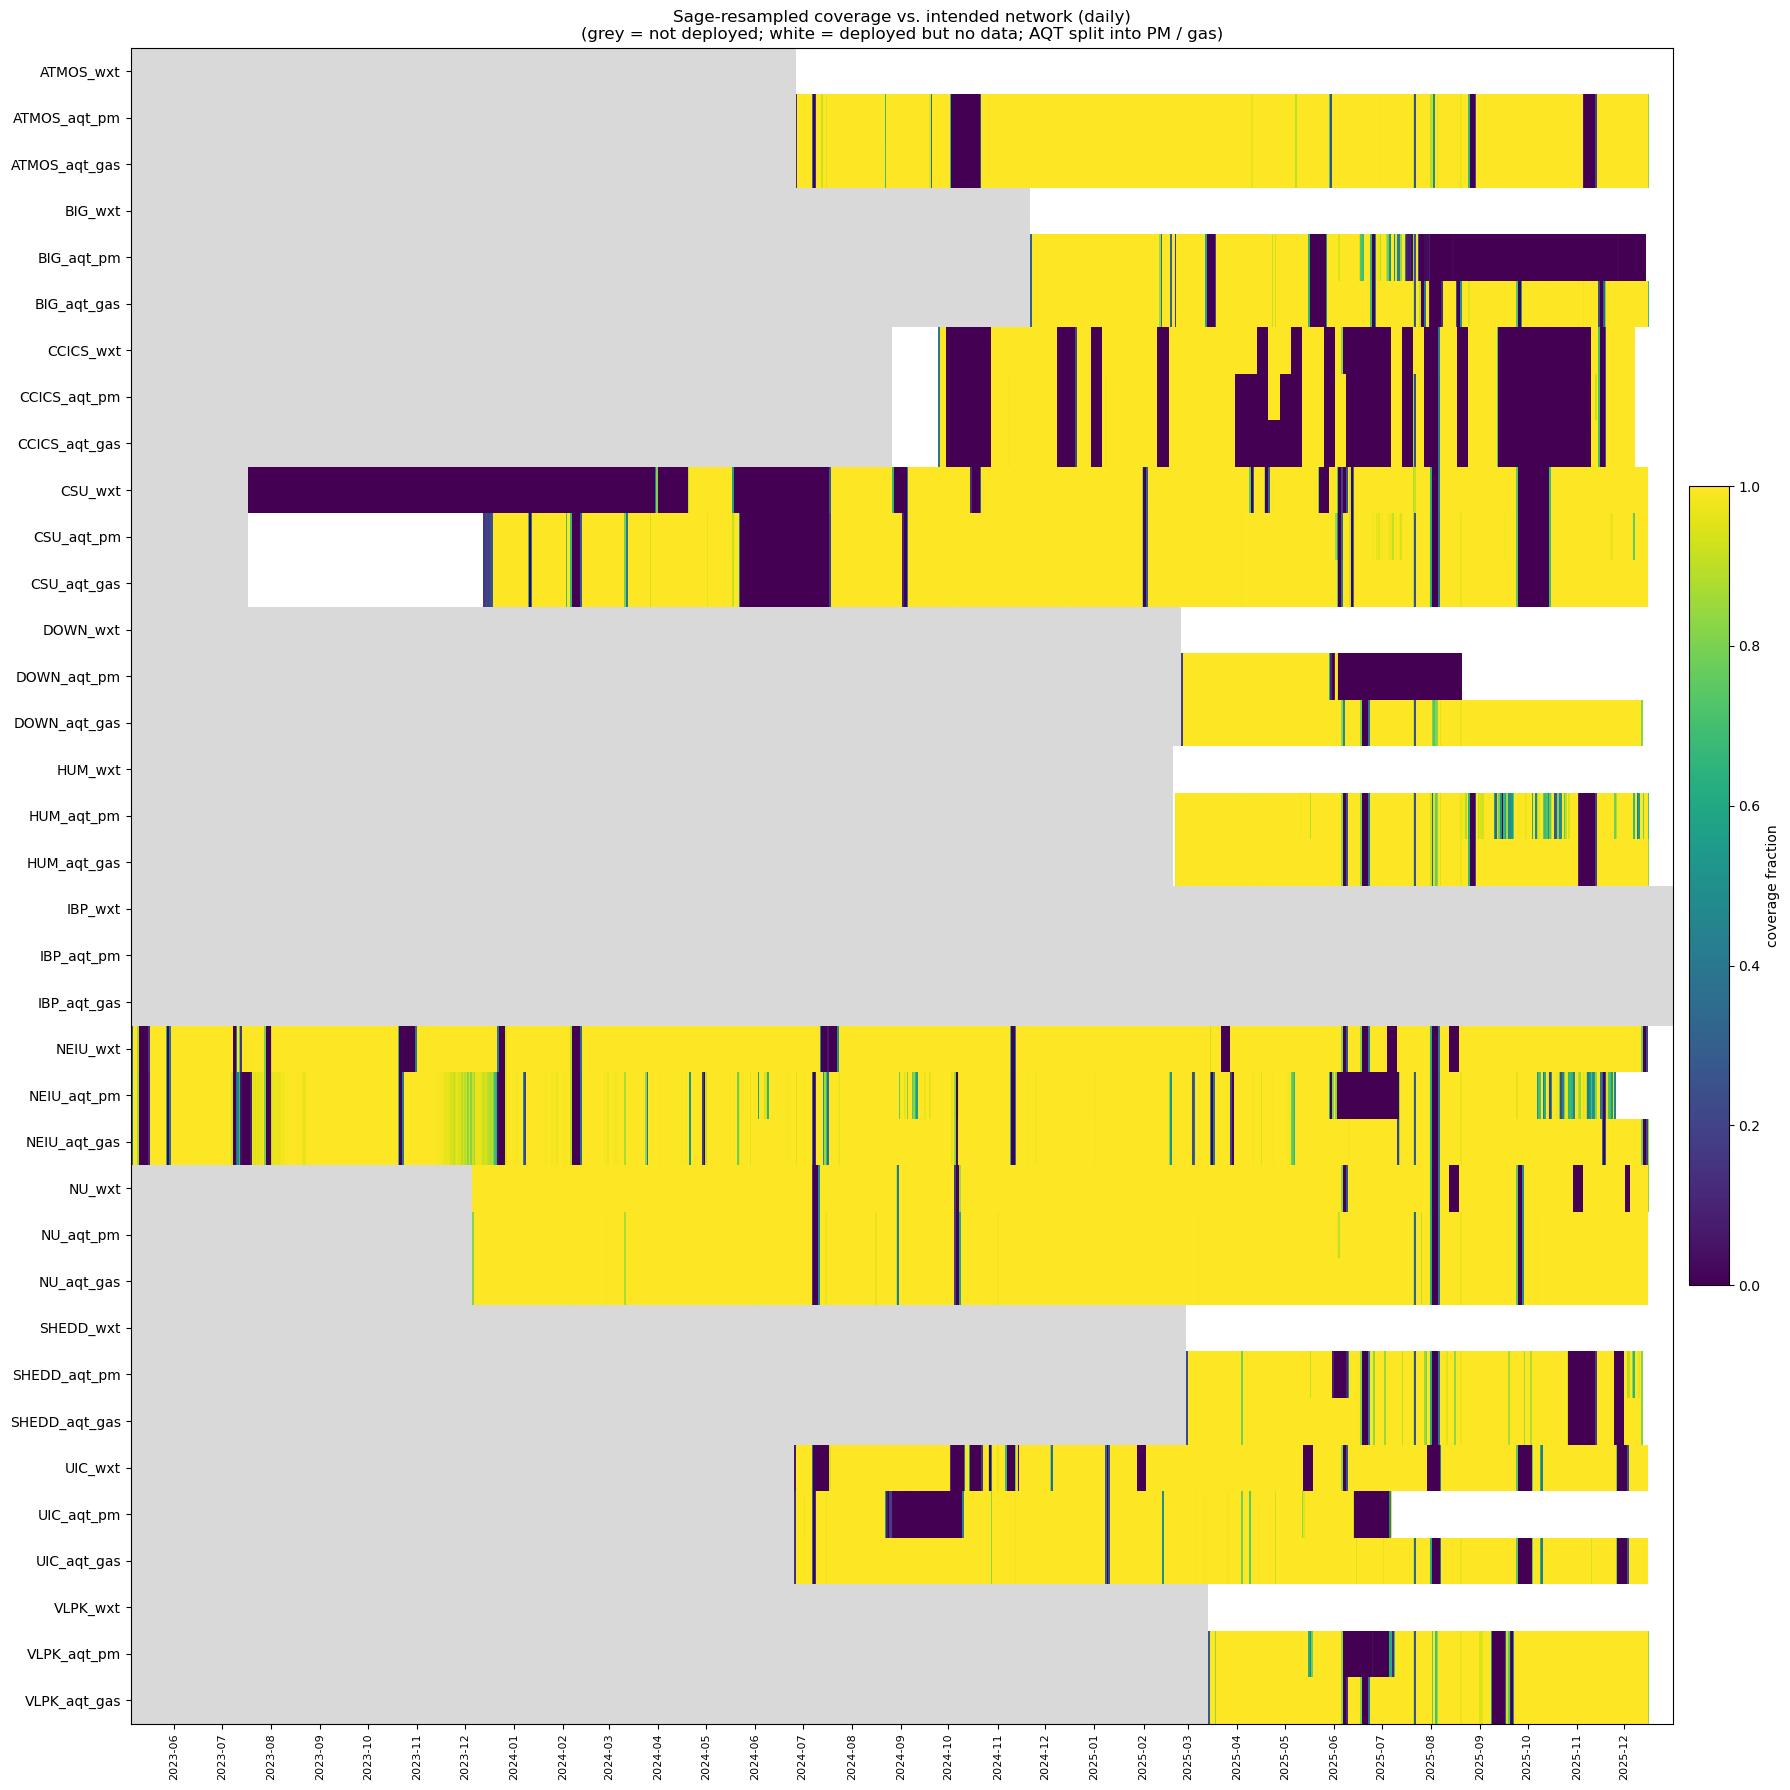

In [16]:
import crocus_sites as cs

REG_TO_ARCHIVE = {}
ARCHIVE_TO_REG = {v: k for k, v in REG_TO_ARCHIVE.items()}
SITE_BY_ABBR = {s.abbr: s for s in cs.ALL_SITES}
ROW_INSTR = {"wxt": "wxt", "aqt_pm": "aqt", "aqt_gas": "aqt"}

def _lookup_site(row_site):
    return SITE_BY_ABBR.get(ARCHIVE_TO_REG.get(row_site, row_site))

def _parse_row(label):
    parts = label.split("_")
    site = parts[0]
    suffix = "_".join(parts[1:]).lower()
    return site, suffix

if cov.empty:
    print("No archives found in", ARCHIVEDIR,
          "- build the resampled archive first.")
else:
    # intended rows: every site's wxt, aqt_pm, aqt_gas, in registry order
    expected_rows = []
    for s in cs.ALL_SITES:
        label_site = REG_TO_ARCHIVE.get(s.abbr, s.abbr)
        for suffix in ("wxt", "aqt_pm", "aqt_gas"):
            expected_rows.append(f"{label_site}_{suffix}")
    extra = [r for r in cov.index if r not in expected_rows]
    all_rows = expected_rows + extra
    covB = cov.reindex(index=all_rows)

    # Daily column axis (was monthly). Sub-pixel days at normal figure width.
    full_days = pd.date_range(covB.columns.min(), "2025-12-31", freq="D")
    covB = covB.reindex(columns=full_days)

    not_deployed = np.zeros(covB.shape, dtype=bool)
    for r, label in enumerate(covB.index):
        site_str, suffix = _parse_row(label)
        site = _lookup_site(site_str)
        instr = ROW_INSTR.get(suffix)
        if site is None or instr is None:
            continue
        for c, day in enumerate(covB.columns):
            if site.deployed(instr, day) is False:
                not_deployed[r, c] = True

    fig, ax = plt.subplots(figsize=(18, max(3, 0.5 * covB.shape[0])))
    im = ax.imshow(covB.values, aspect="auto", cmap="viridis",
                   vmin=0, vmax=1, interpolation="nearest")
    grey = np.ma.masked_where(~not_deployed, np.ones_like(covB.values))
    ax.imshow(grey, aspect="auto", interpolation="nearest",
              cmap=mcolors.ListedColormap(["#d9d9d9"]), vmin=0, vmax=1)

    ax.set_yticks(range(covB.shape[0]))
    ax.set_yticklabels(covB.index)

    month_starts = [i for i, d in enumerate(covB.columns) if d.day == 1]
    month_labels = [covB.columns[i].strftime("%Y-%m") for i in month_starts]
    step = max(1, len(month_starts) // 24)
    ax.set_xticks(month_starts[::step])
    ax.set_xticklabels(month_labels[::step], rotation=90, fontsize=8)

    ax.set_title("Sage-resampled coverage vs. intended network (daily)\n"
                 "(grey = not deployed; white = deployed but no data; "
                 "AQT split into PM / gas)")
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("coverage fraction")
    plt.tight_layout()
    fig.savefig(os.path.join(FIGDIR, "sage_resampled_coverage_deployment.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

**Reading the heatmap.** Each row is a site subsystem; each column a month. Brightness is
the fraction of expected 5-minute steps present. The two AQT rows per site let you see the
PM-vs-gas divergence directly: a bright `_gas` row over a white/dark `_pm` row is the classic
"PM optical module dead, gas cells fine" case.

**Tuning the split.** `classify_aqt_var` is deliberately transparent — if the sanity-check
cell shows a variable landing in the wrong bucket (or T/RH/P should count toward PM instead
of gas), adjust the token tuples at the top. Everything downstream keys off that one
function.